In [6]:
'''!pip install -q -U watermark
!pip install -q google-cloud-bigquery
!pip install -q db-dtypes'''

'!pip install -q -U watermark\n!pip install -q google-cloud-bigquery\n!pip install -q db-dtypes'

In [7]:
import os
import joblib
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import sklearn
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.model_selection import GridSearchCV
from google.cloud import bigquery
from sklearn import metrics
import warnings
warnings.filterwarnings("ignore")

In [8]:
%reload_ext watermark
%watermark -a "Matheus dos Anjos" --iversions

Author: Matheus dos Anjos

joblib    : 1.5.2
matplotlib: 3.10.8
numpy     : 2.3.5
pandas    : 2.3.3
seaborn   : 0.13.2
sklearn   : 1.8.0



In [9]:
os.environ["GOOGLE_APPLICATION_CREDENTIALS"] = "cap05-487217-11730de1694f.json"

In [10]:
client = bigquery.Client()

In [11]:
query = """SELECT * FROM `cap05-487217.Local_ML.dados_historicos`"""

In [12]:
df = client.query(query).to_dataframe()

In [13]:
df.head(3)

,life_expectancy,adult_mortality,diphtheria,hiv,thinness_till19,school,lifestyle
0,81.3,66,92,0.1,0.7,19.0,660.000
1,81.0,67,92,0.1,0.7,20.3,633.450
2,79.9,73,92,0.1,0.7,20.1,586.464


In [14]:
df_dicionario = {
    "life_expectancy": "Expectativa de vida ao nascer, em anos",
    "adult_mortality": "Taxa de mortalidade de adultos entre 15 e 60 anos por 1000 habitantes",
    "diphtheria": "Cobertura de vacinação contra difteria, tétano e coqueluche (DTP3) em crianças de 1 ano (%)"
}

In [15]:
df_dicionario['adult_mortality']

'Taxa de mortalidade de adultos entre 15 e 60 anos por 1000 habitantes'

In [16]:
X = df[['hiv', 'adult_mortality', 'school', 'thinness_till19', 'lifestyle', 'diphtheria']].values
y = df.life_expectancy.values.reshape(-1,1)

In [17]:
x_treino, x_teste, y_treino, y_teste = train_test_split(X, y, test_size = 0.2, random_state = 0)

In [18]:
df_scaler = StandardScaler()

In [19]:
df_scaler.fit(x_treino)

,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True


In [20]:
x_treino_scaled = df_scaler.transform(x_treino)
x_teste_scaled = df_scaler.transform(x_teste)

In [21]:
x_treino_scaled

array([[-0.26678541,  0.0436659 ,  0.0553443 ,  0.9700459 , -0.17289821,
         0.6597978 ],
       [-0.33963615, -1.28892269,  1.96450691, -0.9829721 ,  1.59812445,
         0.31407169],
       [-0.33963615, -0.81242132,  2.69880022, -0.95825036,  0.10846347,
         0.41285058],
       ...,
       [-0.33963615, -0.64281913,  0.82635227,  0.35200223, -0.82996084,
         0.46224002],
       [-0.21214737,  0.49593839, -0.34851703,  0.45088922, -0.85287648,
         0.11651391],
       [-0.33963615,  0.34248879,  0.75292294, -0.21659795, -0.31816218,
         0.56101891]], shape=(1618, 6))

In [22]:
x_treino_scaled.shape

(1618, 6)

In [23]:
x_teste_scaled.shape

(405, 6)

In [24]:
modelo_v1 = LinearRegression()

In [25]:
modelo_v1.fit(x_treino_scaled, y_treino)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [26]:
y_pred_treino_v1 = modelo_v1.predict(x_treino_scaled)

In [27]:
print('Mean Absolute Error:', metrics.mean_absolute_error(y_treino, y_pred_treino_v1))
print('Mean Squared Error:', metrics.mean_squared_error(y_treino, y_pred_treino_v1))
print('Root Mean Squared Error:', np.sqrt(metrics.mean_squared_error(y_treino, y_pred_treino_v1)))
print('R2 Score:', metrics.r2_score(y_treino, y_pred_treino_v1))

Mean Absolute Error: 3.256385493197413
Mean Squared Error: 18.580637791690528
Root Mean Squared Error: 4.310526393805115
R2 Score: 0.7724451327640458


In [28]:
y_pred_teste_v1 = modelo_v1.predict(x_teste_scaled)

In [29]:
df_previsoes = pd.DataFrame({'Valor_Real': y_teste.flatten(), 'Valor_Previsto': y_pred_teste_v1.flatten()})

In [30]:
df_previsoes.head()

,Valor_Real,Valor_Previsto
0,51.9,62.388064
1,66.3,68.491542
2,76.7,72.692093
3,79.9,82.703359
4,58.0,51.483456


In [31]:
def cria_scatter(x, y, title, xlabel, ylabel):

    fig, ax = plt.subplots(figsize = (10,6))

    ax.scatter(x, y, color = "blue", alpha = 0.3)

    ax.set_title(title)
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)

    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

    return

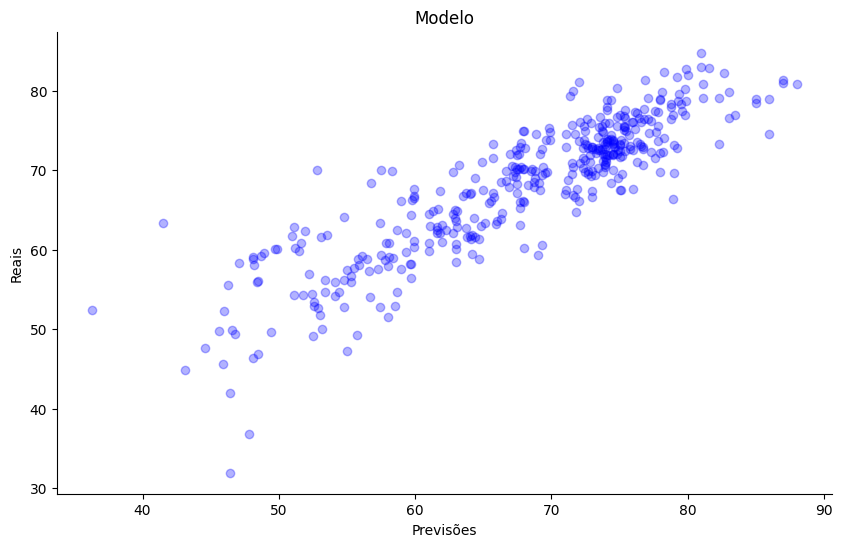

In [32]:
cria_scatter(df_previsoes.Valor_Real, df_previsoes.Valor_Previsto, 'Modelo', 'Previsões', 'Reais')

In [33]:
print('Mean Absolute Error:', metrics.mean_absolute_error(y_teste, y_pred_teste_v1))
print('Mean Squared Error:', metrics.mean_squared_error(y_teste, y_pred_teste_v1))
print('Root Mean Squared Error:', np.sqrt(metrics.mean_squared_error(y_teste, y_pred_teste_v1)))
print('R2 Score:', metrics.r2_score(y_teste, y_pred_teste_v1))

Mean Absolute Error: 3.3791154613120975
Mean Squared Error: 21.212187738719063
Root Mean Squared Error: 4.60566908697521
R2 Score: 0.7750972203450276


In [36]:
modelo_v2 = Ridge()

In [37]:
parametros = {'alpha': [0.1, 1.0, 10.0, 100]}

In [38]:
grid_search = GridSearchCV(estimator = modelo_v2,
                           param_grid = parametros,
                           cv = 5,
                           scoring = 'neg_mean_squared_error',
                           verbose = 1)

In [39]:
grid_search.fit(x_treino_scaled, y_treino) 

Fitting 5 folds for each of 4 candidates, totalling 20 fits


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Ridge()
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'alpha': [0.1, 1.0, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'neg_mean_squared_error'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is displayed;- >2 : the score is also displayed;- >3 : the fold and candidate parameter

In [40]:
melhor_modelo = grid_search.best_estimator_

In [41]:
y_pred_treino_v2 = melhor_modelo.predict(x_treino_scaled)

In [44]:
print('Mean Absolute Error:', metrics.mean_absolute_error(y_treino, y_pred_treino_v2))
print('Mean Squared Error:', metrics.mean_squared_error(y_treino, y_pred_treino_v2))
print('Root Mean Squared Error:', np.sqrt(metrics.mean_squared_error(y_treino, y_pred_treino_v2)))
print('R2 Score:', metrics.r2_score(y_treino, y_pred_treino_v2))

Mean Absolute Error: 3.2571011437459574
Mean Squared Error: 18.58138135489767
Root Mean Squared Error: 4.310612642641145
R2 Score: 0.77243602643364


In [46]:
y_pred_teste_v2 = melhor_modelo.predict(x_teste_scaled)

In [47]:
print('Mean Absolute Error:', metrics.mean_absolute_error(y_teste, y_pred_teste_v2))
print('Mean Squared Error:', metrics.mean_squared_error(y_teste, y_pred_teste_v2))
print('Root Mean Squared Error:', np.sqrt(metrics.mean_squared_error(y_teste, y_pred_teste_v2)))
print('R2 Score:', metrics.r2_score(y_teste, y_pred_teste_v2))

Mean Absolute Error: 3.3808162708913256
Mean Squared Error: 21.21941038321888
Root Mean Squared Error: 4.606453123957616
R2 Score: 0.7750206420663287


In [48]:
print('Melhor Alpha:', grid_search.best_params_['alpha'])

Melhor Alpha: 10.0


In [49]:
print('RMSE V1:', np.sqrt(metrics.mean_squared_error(y_teste, y_pred_teste_v1)))
print('RMSE V2:', np.sqrt(metrics.mean_squared_error(y_teste, y_pred_teste_v2)))

RMSE V1: 4.60566908697521
RMSE V2: 4.606453123957616


In [50]:
print('R2 Score Modelo V1:', metrics.r2_score(y_teste, y_pred_teste_v1))
print('R2 Score Modelo V2:', metrics.r2_score(y_teste, y_pred_teste_v2)) 

R2 Score Modelo V1: 0.7750972203450276
R2 Score Modelo V2: 0.7750206420663287


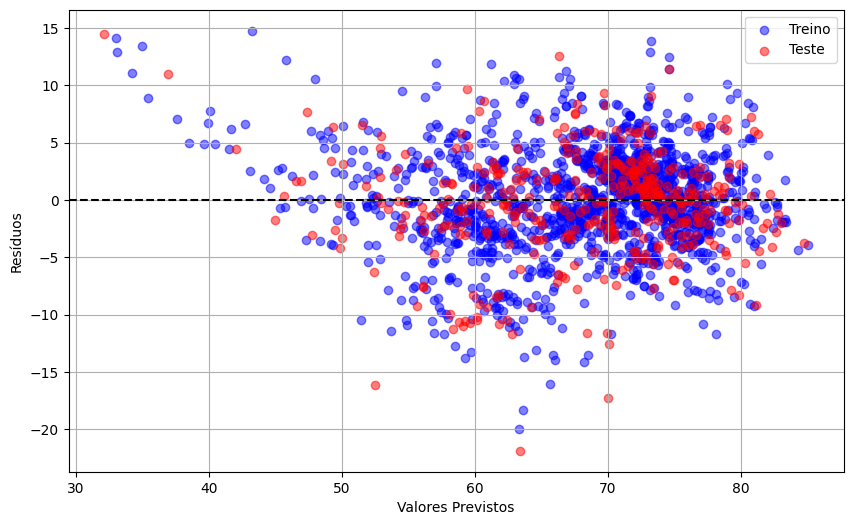

In [54]:
residuos_treino = y_treino - y_pred_treino_v1
residuos_teste = y_teste - y_pred_teste_v1

plt.figure(figsize = (10,6))
plt.scatter(y_pred_treino_v1, residuos_treino, color = 'blue', label = 'Treino', alpha = 0.5)
plt.scatter(y_pred_teste_v2, residuos_teste, color = 'red', label = 'Teste', alpha = 0.5)
plt.axhline(y = 0, color = 'black', linestyle = '--')
plt.xlabel('Valores Previstos')
plt.ylabel('Resíduos')
plt.legend()
plt.grid(True)
plt.show()

In [56]:
joblib.dump(df_scaler, 'df_scaler.pkl')

['df_scaler.pkl']

In [57]:
joblib.dump(modelo_v1, 'modelo_v1.pkl')

['modelo_v1.pkl']